In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

import src.settings as sts
from src.preprocessing.text_preprocessing_pipeline import apply_text_preprocessing_pipeline

In [2]:
df_train_zero_shot: pd.DataFrame = pd.read_csv(sts.FILEPATH_DATA_FINAL_TRAIN_ZEROSHOT_CSV)
df_train_one_shot: pd.DataFrame = pd.read_csv(sts.FILEPATH_DATA_FINAL_TRAIN_ONESHOT_CSV)
df_test: pd.DataFrame = pd.read_csv(sts.FILEPATH_DATA_FINAL_TEST_CSV)
df_augmented: pd.DataFrame = pd.read_csv(sts.FILEPATH_DATA_FINAL_TRAIN_ZEROSHOT_AUGMENTED_CSV)

In [3]:
# Count languages in the splits
print(f"Train Zero-Shot: {df_train_zero_shot["Language"].value_counts()}\n")
print(f"Train Zero-Shot Sum: {df_train_zero_shot["Language"].value_counts().sum()}\n")
print(f"Train One-Shot: {df_train_one_shot["Language"].value_counts()}\n")
print(f"Train One-Shot Sum: {df_train_one_shot["Language"].value_counts().sum()}\n")
print(f"Test: {df_test["Language"].value_counts()}\n")
print(f"Test Sum: {df_test["Language"].value_counts().sum()}\n")

Train Zero-Shot: Language
EN    3327
PT    1164
Name: count, dtype: int64

Train Zero-Shot Sum: 4491

Train One-Shot: Language
EN    73
PT    73
GL    63
Name: count, dtype: int64

Train One-Shot Sum: 209

Test: Language
EN    466
PT    273
Name: count, dtype: int64

Test Sum: 739



### Plot class distribution for zero-shot data

Train Zero-Shot: Language  Label
EN        0        1760
          1        1565
PT        0         773
          1         391
Name: count, dtype: int64
Test: Language  Label
EN        1        284
          0        182
PT        0        154
          1        119
Name: count, dtype: int64


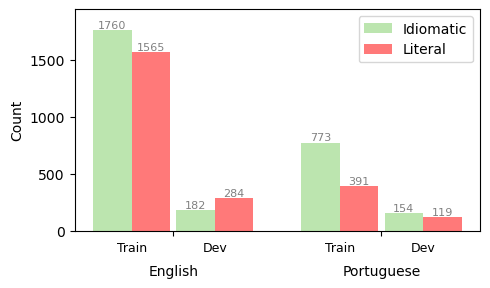

In [50]:
# Count classes in the splits
print(f"Train Zero-Shot: {df_train_zero_shot.groupby("Language")["Label"].value_counts()}")
print(f"Test: {df_test.groupby("Language")["Label"].value_counts()}")

# Compute counts for each (Language, Label) combination for each split
train_counts = df_train_zero_shot.groupby(["Language", "Label"]).size().reset_index(name="Count")
train_counts["Split"] = "Train"
test_counts = df_test.groupby(["Language", "Label"]).size().reset_index(name="Count")
test_counts["Split"] = "Dev"

# Combine the two DataFrames
combined_counts = pd.concat([train_counts, test_counts], ignore_index=True)

# Pivot the data so that rows are Languages and columns are a combination of Split and Label
pivot_df = combined_counts.pivot_table(index="Language", columns=["Split", "Label"], values="Count", fill_value=0)
pivot_df = pivot_df.sort_index(axis=1, level=0)  # Ensure Train comes before Dev

# Map abbreviated language labels to full names
language_map = {"PT": "Portuguese", "EN": "English"}
languages = pivot_df.index.tolist()
mapped_languages = [language_map.get(lang, lang) for lang in languages]

# Define unique labels and splits (assuming 2 labels, e.g., 0 and 1)
unique_labels = sorted(combined_counts["Label"].unique())  # e.g., [0, 1]
splits = ["Train", "Dev"]

# Parameters for bar plotting
bar_width = 0.12      # width of each bar
group_gap = 0.02      # gap between Train and Dev groups
n_labels = len(unique_labels)  # number of bars per group (here, 2)
train_group_width = n_labels * bar_width
dev_group_width = n_labels * bar_width
total_group_width = train_group_width + group_gap + dev_group_width

# Compute base offset so that the total group is centered over each language tick
base_offset = - total_group_width / 2 + bar_width / 2

# x positions for language groups (scaled to reduce space between languages)
x = np.arange(len(languages)) * 0.65

fig, ax = plt.subplots(figsize=(5, 3))

# Define color mapping solely by label:
# label 0 (Idiomatic) is light green, label 1 (Literal) is light red.
color_map = {0: "#a0db8e", 1: "#ff4040"}
alpha_val = 0.7  # transparency for bars

# Plot Train group bars (adjacent, no gap between them)
for i, label in enumerate(unique_labels):
    positions = x + base_offset + i * bar_width
    if ("Train", label) in pivot_df.columns:
        counts = pivot_df[("Train", label)]
    else:
        counts = pd.Series([0] * len(languages), index=languages)
    ax.bar(positions, counts, width=bar_width, color=color_map[label], alpha=alpha_val)
    # Annotate each Train bar with its count in small grey letters
    for j, count in enumerate(counts):
        ax.text(positions[j], count + 0.02, f"{int(count)}", ha="center", va="bottom", color="grey", fontsize=8)

# Plot Dev group bars (adjacent, starting after a gap)
for i, label in enumerate(unique_labels):
    positions = x + base_offset + train_group_width + group_gap + i * bar_width
    if ("Dev", label) in pivot_df.columns:
        counts = pivot_df[("Dev", label)]
    else:
        counts = pd.Series([0] * len(languages), index=languages)
    ax.bar(positions, counts, width=bar_width, color=color_map[label], alpha=alpha_val)
    # Annotate each Dev bar with its count
    for j, count in enumerate(counts):
        ax.text(positions[j], count + 0.02, f"{int(count)}", ha="center", va="bottom", color="grey", fontsize=8)

# Remove default x-axis labels
ax.set_xticks(x)
ax.set_xticklabels([])

ax.set_ylabel("Count")
# ax.set_title("Counts by Language, Split, and Label")

# Calculate midpoints for each group:
train_first = x + base_offset
train_last  = x + base_offset + (n_labels - 1) * bar_width
dev_first = x + base_offset + train_group_width + group_gap
dev_last  = x + base_offset + train_group_width + group_gap + (n_labels - 1) * bar_width

for i in range(len(languages)):
    train_mid = (train_first[i] + train_last[i]) / 2
    dev_mid = (dev_first[i] + dev_last[i]) / 2
    # Place split labels directly under their groups
    ax.text(train_mid, -0.05, "Train", ha="center", va="top", transform=ax.get_xaxis_transform(), fontsize=9)
    ax.text(dev_mid, -0.05, "Dev", ha="center", va="top", transform=ax.get_xaxis_transform(), fontsize=9)
    # Place language labels further below, centered on the language tick
    ax.text(x[i], -0.15, mapped_languages[i], ha="center", va="top", transform=ax.get_xaxis_transform(), fontsize=10)

# Add extra padding at the top of the plot
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.05)

# Create a custom legend with only two entries: Idiomatic and Literal.
custom_handles = [
    Patch(facecolor=color_map[0], alpha=alpha_val, label="Idiomatic"),
    Patch(facecolor=color_map[1], alpha=alpha_val, label="Literal")
]
ax.legend(handles=custom_handles, loc="upper right")

# ax.set_yticklabels([])
# ax.set_yticks([])

plt.tight_layout()
plt.savefig(sts.DIR_PATH_RESULTS_EXPLORATIVE_DATA_ANALYSIS_PLOTS / "class_distribution_zero_shot_train_and_dev.png")
plt.savefig(sts.DIR_PATH_RESULTS_EXPLORATIVE_DATA_ANALYSIS_PLOTS / "class_distribution_zero_shot_train_and_dev.pdf")
plt.show()


### Plot sequence lengths distribution for zero-shot data

2853
Train Zero Shot:
Min: 16
Max: 286
Median: 70.0

Test:
Min: 22
Max: 182
Median: 67.0


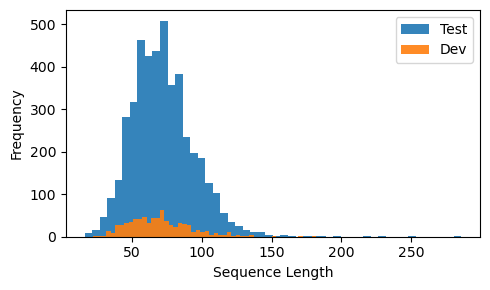

In [49]:
# Load the DataFrames
df_train_zero_shot: pd.DataFrame = pd.read_csv(sts.FILEPATH_DATA_FINAL_TRAIN_ZEROSHOT_CSV)
df_test: pd.DataFrame = pd.read_csv(sts.FILEPATH_DATA_FINAL_TEST_CSV)

# Combine 3 sentences into the "text" column and apply text preprocessing
df_train_zero_shot = apply_text_preprocessing_pipeline(df_train_zero_shot, process_mwe=False)
df_test = apply_text_preprocessing_pipeline(df_test, process_mwe=False)

# Remove rows with NaN in the "text" column for the train dataset
df_train_zero_shot = df_train_zero_shot.dropna(subset=["text"])

# Remove rows with NaN in the "text" column for the test dataset
df_test = df_test.dropna(subset=["text"])

# Calculate the sequence length (number of words) for each text
df_train_zero_shot["sequence length"] = df_train_zero_shot["text"].apply(lambda _x: len(str(_x).split()))
df_test["sequence length"] = df_test["text"].apply(lambda _x: len(str(_x).split()))

# Calculate statistics for the train DataFrame
print(df_train_zero_shot["sequence length"].idxmin())
train_min = df_train_zero_shot["sequence length"].min()
train_max = df_train_zero_shot["sequence length"].max()
train_median = df_train_zero_shot["sequence length"].median()

# Calculate statistics for the test DataFrame
test_min = df_test["sequence length"].min()
test_max = df_test["sequence length"].max()
test_median = df_test["sequence length"].median()

# Print the results for the train DataFrame
print("Train Zero Shot:")
print("Min:", train_min)
print("Max:", train_max)
print("Median:", train_median)

# Print the results for the test DataFrame
print("\nTest:")
print("Min:", test_min)
print("Max:", test_max)
print("Median:", test_median)

fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(df_train_zero_shot["sequence length"], bins=50, alpha=0.9, label="Test")
ax.hist(df_test["sequence length"], bins=50, alpha=0.9, label="Dev")
ax.set_xlabel("Sequence Length")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.savefig(sts.DIR_PATH_RESULTS_EXPLORATIVE_DATA_ANALYSIS_PLOTS / "sequence_length_zero_shot_train_and_dev.png")
plt.savefig(sts.DIR_PATH_RESULTS_EXPLORATIVE_DATA_ANALYSIS_PLOTS / "sequence_length_zero_shot_train_and_dev.pdf")
plt.show()